# Focal-plane distortions — keystone, smile, clocking

`geocarb_gert.FocalPlaneModel` maps hi-res (line-by-line) radiance onto a discrete
detector array (spatial × spectral) with GeoCarb's optical distortions — **keystone**,
**smile**, **clocking** — plus the **N/S PSF**. Two detectors are used below:

* **real detector** — the GeoCarb CO₂-weak focal plane: a **1024-px slit**, the slit
  image growing **20 px blue→red** (`keystone_px=20`, 1.95 %), **1.5-px** N/S PSF. Used
  for the *spatial* panels (keystone, patchwork).
* **viz detector** — a zoomed 40 cm⁻¹ sub-window so individual CO₂ lines are legible.
  Used for the *spectral-line* panels (smile, clocking), one distortion at a time.

In [18]:
import sys, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
GERT_ROOT = Path('../../../gert').resolve()

import geosat_geometry as gg
from geocarb_gert import (build_geocarb_instrument, sample_geometries,
                          reference_atmosphere, albedo_for,
                          FocalPlaneModel, uniform_scene, edge_scene,random_scene)
import gert
from gert.forward_model import ForwardModel
from gert.rt_solver import VectorDOSolver

block = gg.geocarb_demo(verbose=False)['blocks'][0]
row, col, geo = sample_geometries(block, n=1, seed=0)[0]
inst  = build_geocarb_instrument()
atm   = reference_atmosphere()
absco = gert.ABSCOTable.load_all(str(GERT_ROOT/'input/absco/absco.h5'))
solar = gert.SolarSpectrum.load(str(GERT_ROOT/'input/solar/solar.h5'))

# One line-by-line forward run per surface -> hi-res radiance for CO2_weak (band 1).
fm = ForwardModel(atm, absco, inst, geo, solver=VectorDOSolver(), solar_spectrum=solar)
B  = 1
def hires(surface):
    res = fm.run(albedo=albedo_for(inst, surface))
    return np.asarray(res.wn_band_hires[B]), np.asarray(res.I_hires[B])
wn_hi, I_desert = hires('desert')
_,     I_water  = hires('water')
_,     I_forest = hires('forest')
_,     I_grass  = hires('grass')
print('CO2_weak hi-res:', wn_hi.size, 'pts  [%.1f, %.1f] cm-1'%(wn_hi[0], wn_hi[-1]))

CO2_weak hi-res: 12001 pts  [6166.0, 6286.0] cm-1


## Detectors

Spectral resolution is taken faithfully from the CO₂-weak ILS (σ = 0.132 cm⁻¹ → FWHM
in nm). `real_det(...)` builds the 1024-px GeoCarb detector over the full band;
`viz_det(...)` builds the zoomed detector for the line-curvature panels.

In [19]:
w    = inst.windows[B]
wn_c = 0.5*(w.wn_min + w.wn_max)
fwhm_nm = 2.3548 * w.ils.sigma / wn_c**2 * 1e7          # cm-1 sigma -> nm FWHM

# --- Real GeoCarb CO2_weak detector: 1024-px slit, slit image grows 20 px blue->red ---
def real_det(**kw):
    p = dict(keystone_px=20.0, smile_px_edge=0.0, clocking_deg=0.0, spatial_psf_fwhm_px=1.5)
    p.update(kw)                                        # slit 18.4 mm / 18 um -> 1024 rows
    return FocalPlaneModel(18.44, 1.0, 18.0, w.wn_min, w.wn_max, 1024, fwhm_nm, **p)

# --- Zoomed viz detector for line-curvature panels (smile / clocking) ---
VZ0, VZ1 = 6210.0, 6250.0
def viz_det(**kw):
    p = dict(keystone_px=0.0, smile_px_edge=0.0, clocking_deg=0.0, spatial_psf_fwhm_px=1.5)
    p.update(kw)                                        # slit 15 mm / 50 um -> 300 rows
    return FocalPlaneModel(15.0, 1.0, 50.0, VZ0, VZ1, 300, fwhm_nm, **p)

fp = real_det()
print('REAL detector: %d rows x %d cols | keystone_frac=%.4f (%.2f%%) -> edge crosses up to %.0f rows | dnu=%.3f cm-1/px'
      % (fp.n_spatial, fp.n_spectral, fp.keystone_frac, 100*fp.keystone_frac, fp.keystone_px/2, fp.dnu))

# hi-res slices: full band (real panels), zoom window (viz panels)
mR = (wn_hi >= w.wn_min-2) & (wn_hi <= w.wn_max+2)
wnR, SdR, SwR, SfR = wn_hi[mR], I_desert[mR], I_water[mR], I_forest[mR]
mZ = (wn_hi >= VZ0-2) & (wn_hi <= VZ1+2)
wnZ, SdZ = wn_hi[mZ], I_desert[mZ]

REAL detector: 1024 rows x 1024 cols | keystone_frac=0.0195 (1.95%) -> edge crosses up to 10 rows | dnu=0.117 cm-1/px


## Smile — a homogeneous bright slit (viz detector)

Every row sees the same desert spectrum, so the CO₂ lines trace the smile curvature
directly. Cyan curves are `line_locus(ν₀)`; the lines bow toward the red at the slit
edges (∝ η²), growing toward the long-wave end.

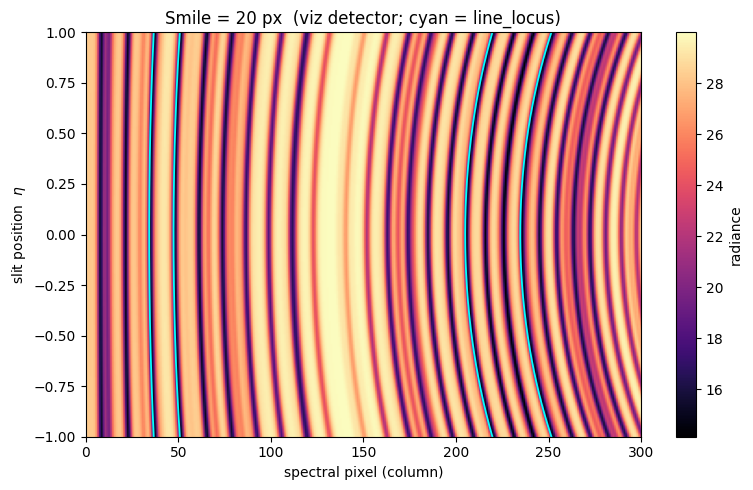

In [17]:
fp_sm = viz_det(smile_px_edge=20.0)
A = fp_sm.image(wnZ, uniform_scene(SdZ))

# strongest distinct absorption lines in-window, for the smile overlay
inb = np.where((wnZ>=VZ0)&(wnZ<=VZ1))[0]
order = inb[np.argsort(SdZ[inb])]
centres = []
for k in order:
    nu = wnZ[k]
    if all(abs(nu-c)>1.5 for c in centres): centres.append(nu)
    if len(centres) >= 4: break
centres = sorted(centres)

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(A, origin='lower', aspect='auto', cmap='magma', extent=[0, fp_sm.n_spectral, -1, 1])
for nu0 in centres:
    ax.plot(fp_sm.line_locus(nu0), fp_sm.eta, color='cyan', lw=1.3)
ax.set_xlabel('spectral pixel (column)'); ax.set_ylabel(r'slit position  $\eta$')
ax.set_title('Smile = %.0f px  (viz detector; cyan = line_locus)' % fp_sm.smile_px_edge)
ax.set_xlim(0, fp_sm.n_spectral); fig.colorbar(im, label='radiance'); fig.tight_layout(); plt.show()

## Keystone — the real GeoCarb detector

The slit image grows **20 px blue→red** (1.95 %), symmetric about the slit centre, so an
edge crosses `η·keystone_px/2` rows across the band — up to **10 rows at the slit ends**,
~0 at centre. Near the ends this leaks *spatial* contrast into an apparent *spectral*
slope: the boundary images as a shallow tilt, and reading along a near-end row the
continuum transitions gradually forest→desert.

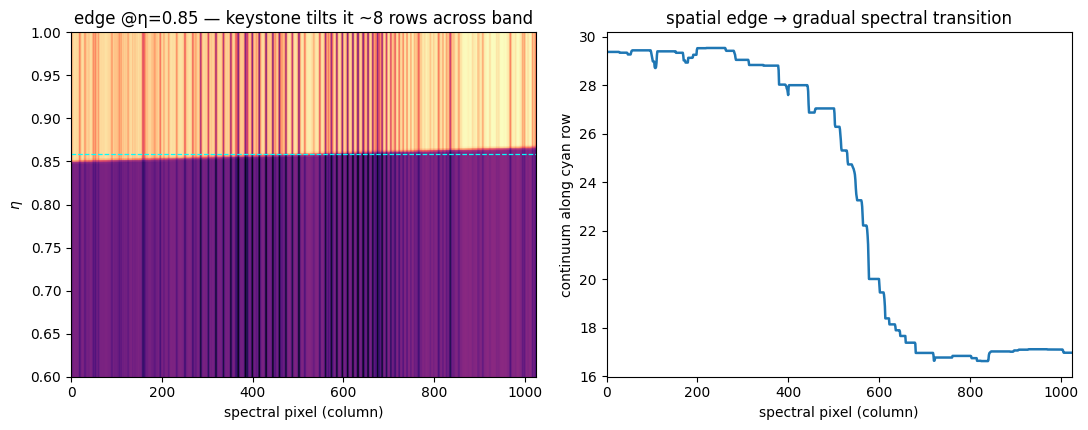

keystone 20 px (1.95%): edge @η=0.85 crosses 8.5 rows across the 1024-px slit


In [20]:
from numpy.lib.stride_tricks import sliding_window_view
fpk = real_det()                       # keystone_px=20, smile 0, clocking 0, PSF 1.5
ETA_E = 0.85                           # edge near the slit end, where keystone bites
A = fpk.image(wnR, edge_scene(SfR, SdR, edge=ETA_E))          # forest -> desert
irow = int(np.argmin(np.abs(fpk.eta - ETA_E*(1+fpk.keystone_frac*0.5))))
env = sliding_window_view(np.pad(A[irow], 20, mode='edge'), 41).max(-1)   # continuum (upper envelope)

fig,(a0,a1) = plt.subplots(1,2, figsize=(11,4.4))
a0.imshow(A, origin='lower', aspect='auto', cmap='magma', extent=[0, fpk.n_spectral, -1, 1])
a0.axhline(fpk.eta[irow], color='cyan', lw=0.9, ls='--'); a0.set_ylim(0.6, 1.0)
a0.set_title('edge @η=%.2f — keystone tilts it ~%.0f rows across band' % (ETA_E, ETA_E*fpk.keystone_px/2))
a0.set_xlabel('spectral pixel (column)'); a0.set_ylabel(r'$\eta$')
a1.plot(env, lw=1.8); a1.set_xlabel('spectral pixel (column)'); a1.set_ylabel('continuum along cyan row')
a1.set_title('spatial edge → gradual spectral transition'); a1.set_xlim(0, fpk.n_spectral)
fig.tight_layout(); plt.show()
print('keystone 20 px (1.95%%): edge @η=%.2f crosses %.1f rows across the %d-px slit'
      % (ETA_E, ETA_E*fpk.keystone_px/2, fpk.n_spatial))

## Clocking — a rotated detector

Clocking is a rigid rotation of the detector, so its spectral signature is a
**linear** tilt (`∝ η`), constant across the band — distinct from smile's
**quadratic** bow (`∝ f·η²`). Same lines, same overlay machinery: smile curves,
clocking tilts.

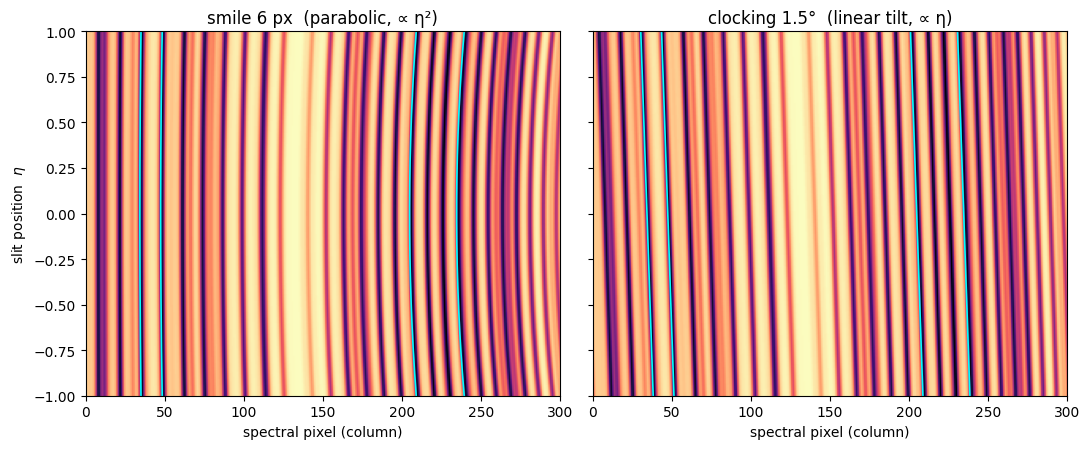

In [5]:
fp_smile = viz_det(smile_px_edge=6.0)
fp_clock = viz_det(clocking_deg=1.5)
A_s = fp_smile.image(wnZ, uniform_scene(SdZ))
A_c = fp_clock.image(wnZ, uniform_scene(SdZ))

fig,(a0,a1) = plt.subplots(1,2, figsize=(11,4.6), sharey=True)
for ax,A,fpx,title in ((a0,A_s,fp_smile,'smile 6 px  (parabolic, ∝ η²)'),
                       (a1,A_c,fp_clock,'clocking 1.5°  (linear tilt, ∝ η)')):
    ax.imshow(A, origin='lower', aspect='auto', cmap='magma', extent=[0, fpx.n_spectral, -1, 1])
    for nu0 in centres:
        ax.plot(fpx.line_locus(nu0), fpx.eta, color='cyan', lw=1.2)
    ax.set_title(title); ax.set_xlabel('spectral pixel (column)'); ax.set_xlim(0, fpx.n_spectral)
a0.set_ylabel(r'slit position  $\eta$')
fig.tight_layout(); plt.show()

## The calibration data product

`wavelength_grid()` returns the per-pixel effective wavenumber `ν_eff[i, j]` — the
smile map a downstream retrieval needs. Feeding this as the **truth** calibration and
retrieving with the nominal grid is how we'd turn smile into an XCO₂/XCH₄ **bias**
(via `gert`'s dispersion-polynomial machinery).

In [6]:
nu_eff = fp_sm.wavelength_grid()
print('nu_eff grid:', nu_eff.shape, 'cm-1')
print('smile range at a red-end column (max |dev| vs nominal): %.3f cm-1 = %.2f px'
      % (np.max(np.abs(nu_eff[:, -1]-fp_sm.nu[-1])),
         np.max(np.abs(nu_eff[:, -1]-fp_sm.nu[-1]))/fp_sm.dnu))

nu_eff grid: (300, 300) cm-1
smile range at a red-end column (max |dev| vs nominal): 2.676 cm-1 = 20.00 px


## Energy conservation — `units='electrons'`

`image()` returns **radiance** by default (the ray-invariant), which is correct for
a lossless remap but is *not* flux-conserving when summed with uniform bins: smile
makes the local dispersion non-uniform. Passing `units='energy'` (alias
`'electrons'`) weights each pixel by its smile-distorted bandwidth `Δλ_eff` and the
keystone plate-scale `1/stretch`, restoring conservation. Below: the band-integrated
signal of a monochromatic line vs slit position — radiance bulges ~2.8 % at the slit
edge, energy stays flat.

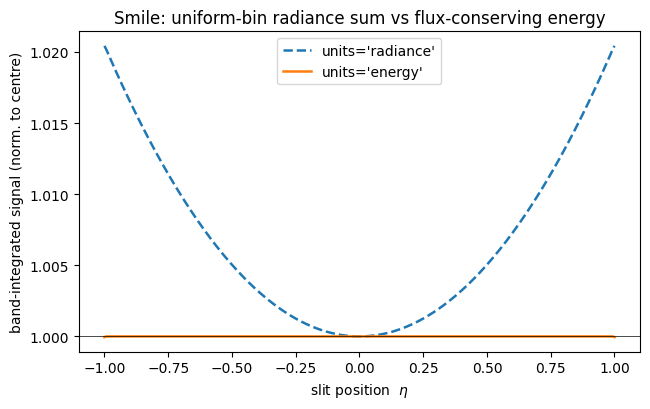

edge/centre  radiance = 1.0204   energy = 0.9999


In [7]:
S_line = np.exp(-0.5*((wnZ-6230.0)/0.03)**2)          # a single monochromatic line
fpE = viz_det(smile_px_edge=6.0)

fig, ax = plt.subplots(figsize=(6.6,4.2))
for mode, ls in (('radiance','--'), ('energy','-')):
    A = fpE.image(wnZ, uniform_scene(S_line), units=mode)
    rs = A.sum(axis=1); rs = rs/rs[fpE.n_spatial//2]
    ax.plot(fpE.eta, rs, ls, lw=1.8, label="units='%s'" % mode)
ax.axhline(1.0, color='k', lw=0.5)
ax.set_xlabel(r'slit position  $\eta$'); ax.set_ylabel('band-integrated signal (norm. to centre)')
ax.set_title('Smile: uniform-bin radiance sum vs flux-conserving energy')
ax.legend(); fig.tight_layout(); plt.show()
print('edge/centre  radiance = %.4f   energy = %.4f'
      % ((lambda A: A.sum(1)[0]/A.sum(1)[fpE.n_spatial//2])(fpE.image(wnZ, uniform_scene(S_line),'radiance')),
         (lambda A: A.sum(1)[0]/A.sum(1)[fpE.n_spatial//2])(fpE.image(wnZ, uniform_scene(S_line),'energy'))))

## Patchwork slit — many transitions on the real detector

`random_scene` splits the 1024-px slit into random segments from a few base spectra
(desert / water / forest). On the real GeoCarb detector (keystone 20 px + clocking + PSF)
the boundaries **splay** (keystone, ∝ distance from centre) and **tilt** (clocking) —
largest at the slit ends, ~0 at centre. Cyan lines mark the nominal boundaries.

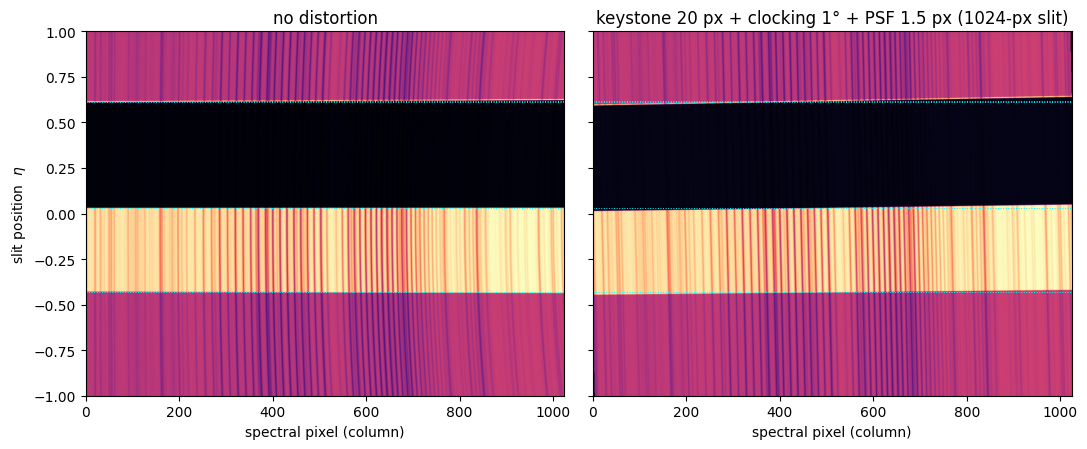

segments: ['forest', 'desert', 'water', 'desert', 'forest'] | boundary η: [-0.43  0.03  0.61  0.62]


In [24]:
scene = random_scene([SdR, SwR, SfR], n_segments=5, seed=5)
fp_flat = real_det(keystone_px=20.,  clocking_deg=0.,  smile_px_edge=20.)
fp_dist = real_det(keystone_px=20., clocking_deg=1.0, smile_px_edge=0.)
A_flat = fp_flat.image(wnR, scene)
A_dist = fp_dist.image(wnR, scene)

fig,(a0,a1) = plt.subplots(1,2, figsize=(11,4.6), sharey=True)
for ax,A,fpx,title in ((a0,A_flat,fp_flat,'no distortion'),
                       (a1,A_dist,fp_dist,'keystone 20 px + clocking 1° + PSF 1.5 px (1024-px slit)')):
    ax.imshow(A, origin='lower', aspect='auto', cmap='magma', extent=[0, fpx.n_spectral, -1, 1])
    for b in scene.boundaries:
        ax.axhline(b, color='cyan', lw=0.7, ls=':')
    ax.set_title(title); ax.set_xlabel('spectral pixel (column)'); ax.set_xlim(0, fpx.n_spectral)
a0.set_ylabel(r'slit position  $\eta$')
fig.tight_layout(); plt.show()
print('segments:', [['desert','water','forest'][i] for i in scene.segment_scenes],
      '| boundary η:', np.round(scene.boundaries, 2))



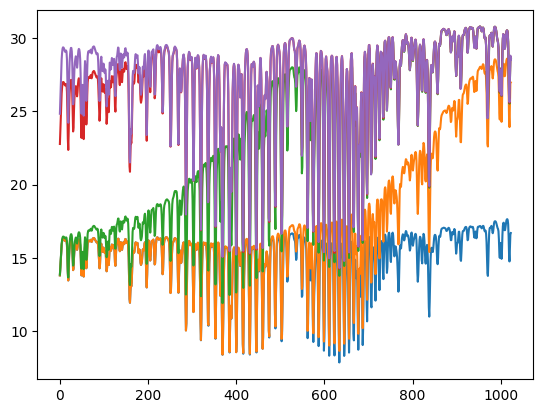

In [32]:
plt.plot(A_flat[int(A_flat.shape[0]//2*(1+scene.boundaries[0])-5):int(A_flat.shape[0]//2*(1+scene.boundaries[0])+5):2].T, label='flat')